# Task 3 - ROC Curve Comparison (ResNet50 vs VGG16 vs DenseNet121)

Loads the three Task 2 models (`task2_resnet_baseline/outputs/resnet50_model.pt`,
`task2_vgg16/outputs/vgg16_model.pt`, `task2_densenet121/outputs/densenet121_model.pt`)
and plots their ROC curves on the same test set, on one shared axis, with AUC in the
legend.

**Positive class convention**: an ROC curve needs one class picked as "positive".
We use **malignant** as the positive class (not an arbitrary choice - in a medical
screening context, the curve that matters is "how well does the model rank
malignant cases above benign ones", i.e. trading off the true positive rate for
malignant detection against the false positive rate). The malignant/benign label
mapping is re-verified from the filenames here, the same way every other notebook
in this project does it, rather than assumed.

All three checkpoints were trained with the exact same data split (`RANDOM_SEED=42`)
and the exact same training method (Task 2's fair-comparison design), so this ROC
comparison isolates the effect of architecture, same as the macro-averaged metrics
in `comparison.md`.


## 1. Imports

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import roc_curve, auc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 2. Load the test set and verify the label mapping

Same verification approach as every Task 1/Task 2 notebook: cross-check the numeric
label against the image filename, never assume which integer means which class.

In [2]:
DATASET_DIR = os.path.expanduser("~/datasets/BUSI")
TRAIN_XLSX = os.path.join(DATASET_DIR, "train.xlsx")
TEST_XLSX = os.path.join(DATASET_DIR, "test.xlsx")
IMAGES_ROOT = os.path.join(DATASET_DIR, "images")
IMAGE_COL, LABEL_COL = "Image", "Label"
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

train_df = pd.read_excel(TRAIN_XLSX)  # only needed for the filename cross-check below
test_df = pd.read_excel(TEST_XLSX)

combined_df = pd.concat([train_df, test_df], ignore_index=True)
name_from_file = combined_df[IMAGE_COL].astype(str).str.extract(r"^([A-Za-z]+)")[0].str.lower()
label_value = combined_df[LABEL_COL]
check_table = pd.crosstab(label_value, name_from_file)

id_to_name = {}
for label_id, row in check_table.iterrows():
    matched_names = row[row > 0].index.tolist()
    assert len(matched_names) == 1
    id_to_name[int(label_id)] = matched_names[0]

CLASS_NAMES = [id_to_name[i] for i in sorted(id_to_name)]
LABEL_MAP = {name: i for i, name in id_to_name.items()}
MALIGNANT_ID = CLASS_NAMES.index("malignant")

print("CLASS_NAMES:", CLASS_NAMES)
print("LABEL_MAP:", LABEL_MAP)
print("MALIGNANT_ID (positive class for the ROC curve):", MALIGNANT_ID)


CLASS_NAMES: ['malignant', 'benign']
LABEL_MAP: {'malignant': 0, 'benign': 1}
MALIGNANT_ID (positive class for the ROC curve): 0


## 3. Dataset and DataLoader (test set only, no augmentation)

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class BUSIDataset(Dataset):
    def __init__(self, df, images_root, image_col, label_col, label_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_root = images_root
        self.image_col = image_col
        self.label_col = label_col
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _to_label_id(self, raw_label):
        if isinstance(raw_label, (int, np.integer)):
            return int(raw_label)
        return self.label_map[str(raw_label).strip().lower()]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_root, str(row[self.image_col]))
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = self._to_label_id(row[self.label_col])
        return image, label


test_dataset = BUSIDataset(test_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"test set: {len(test_dataset)} samples")


test set: 130 samples


## 4. Load each trained model and collect malignant-class probabilities

Each architecture needs its classification head rebuilt exactly as its own Task 2
notebook built it (plain `Linear` layer, full fine-tuning, no dropout) before the
saved `state_dict` can be loaded.

In [4]:
def build_resnet50():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
    return model


def build_vgg16():
    model = models.vgg16(weights=None)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, len(CLASS_NAMES))
    return model


def build_densenet121():
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, len(CLASS_NAMES))
    return model


MODEL_SPECS = {
    "ResNet50": (build_resnet50, os.path.expanduser("~/projects/research_training/task2_resnet_baseline/outputs/resnet50_model.pt")),
    "VGG16": (build_vgg16, os.path.expanduser("~/projects/research_training/task2_vgg16/outputs/vgg16_model.pt")),
    "DenseNet121": (build_densenet121, os.path.expanduser("~/projects/research_training/task2_densenet121/outputs/densenet121_model.pt")),
}


@torch.no_grad()
def get_malignant_probs(model):
    model.eval()
    all_probs = []
    for images, _ in test_loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs[:, MALIGNANT_ID].cpu().numpy())
    return np.concatenate(all_probs)


# True labels, in the same order as test_loader (shuffle=False), reused for every model.
true_labels = np.array([test_dataset[i][1] for i in range(len(test_dataset))])
true_malignant_binary = (true_labels == MALIGNANT_ID).astype(int)

model_probs = {}
for name, (builder, path) in MODEL_SPECS.items():
    model = builder()
    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device)
    model_probs[name] = get_malignant_probs(model)
    print(f"{name}: loaded from {path}, {len(model_probs[name])} test predictions collected")


ResNet50: loaded from /mnt/cv_data/users/hahaxixi/projects/research_training/task2_resnet_baseline/outputs/resnet50_model.pt, 130 test predictions collected


VGG16: loaded from /mnt/cv_data/users/hahaxixi/projects/research_training/task2_vgg16/outputs/vgg16_model.pt, 130 test predictions collected


DenseNet121: loaded from /mnt/cv_data/users/hahaxixi/projects/research_training/task2_densenet121/outputs/densenet121_model.pt, 130 test predictions collected


## 5. Plot the three ROC curves on one shared axis

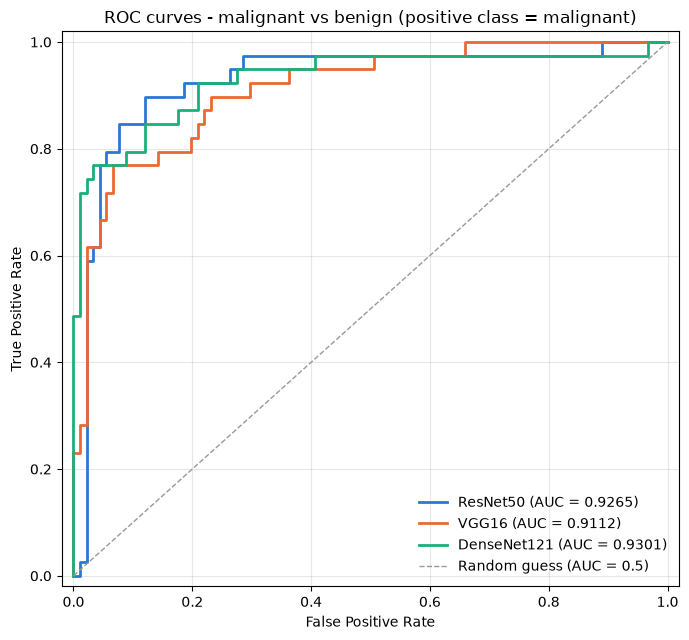

AUC scores:
  ResNet50: 0.9265
  VGG16: 0.9112
  DenseNet121: 0.9301
Saved to roc_comparison.png


In [5]:
# Categorical colors (colorblind-safe, fixed order - not cycled per series)
COLORS = {"ResNet50": "#2a78d6", "VGG16": "#eb6834", "DenseNet121": "#1baf7a"}

fig, ax = plt.subplots(figsize=(7, 6.5))
auc_scores = {}

for name in MODEL_SPECS:
    fpr, tpr, _ = roc_curve(true_malignant_binary, model_probs[name])
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    ax.plot(fpr, tpr, color=COLORS[name], linewidth=2, label=f"{name} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", linewidth=1, label="Random guess (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves - malignant vs benign (positive class = malignant)")
ax.legend(loc="lower right", frameon=False)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("AUC scores:")
for name, score in auc_scores.items():
    print(f"  {name}: {score:.4f}")
print("Saved to roc_comparison.png")

import json
with open("roc_comparison_results.json", "w") as f:
    json.dump({"auc": auc_scores, "positive_class": "malignant"}, f, indent=2)


## 6. Observations

Based on the actual curves and AUC values computed above (test set, n=130: 39 malignant / 91 benign):

- **AUC ranking**: DenseNet121 (0.9301) > ResNet50 (0.9265) > VGG16 (0.9112). All three are
  clearly well above the random-guess baseline (AUC=0.5) and fairly close to each other -
  the spread between the best and worst is only about 0.019 AUC, so architecture choice
  matters here, but not dramatically, under this fair-comparison training recipe.
- **Low-false-positive region (FPR near 0)**: DenseNet121's curve starts the highest -
  at FPR=0 it already achieves TPR=0.487 (i.e. its single most confident prediction and
  several after it are correctly malignant with zero false positives), versus VGG16's
  TPR=0.231 and ResNet50's TPR=0.000 at the same point. This means DenseNet121's most
  confident malignant predictions are the most trustworthy of the three models.
- **Mid FPR region (0.05-0.2)**: ResNet50 catches up and overtakes DenseNet121 - at
  FPR=0.1, ResNet50 reaches TPR=0.846 versus DenseNet121's 0.795 and VGG16's 0.769; at
  FPR=0.2, ResNet50 leads further (TPR=0.923 vs. 0.872 vs. 0.821). So ResNet50's ROC
  curve is initially weaker at the very-low-FPR end but becomes the strongest curve
  through the middle of the range, which is part of why its overall AUC ends up close
  to DenseNet121's despite starting behind.
- **VGG16 is the weakest of the three across almost the entire curve** (lowest or
  tied-lowest TPR at every FPR checkpoint above), consistent with it also having the
  lowest test accuracy/macro-F1 among the three in section 11 of its own notebook.
- **Connecting back to the macro-F1 results at the default 0.5 threshold**: DenseNet121's
  strong low-FPR performance here is consistent with its test-set numbers being
  precision-heavy (precision_macro=0.9021, recall_macro=0.8553) - it tends to only call
  "malignant" when quite confident. ResNet50's more even TPR gain across the whole curve
  matches its more balanced precision/recall (0.8792 / 0.8846) at the same threshold.
  VGG16's uniformly weaker curve matches its flatter, more modest 0.8352/0.8352/0.8352
  precision/recall/F1 profile.
- **Caveat**: with only 39 malignant test images, each curve is built from a small
  number of points (the visible "staircase" shape in the raw fpr/tpr arrays), so small
  differences in AUC (e.g. DenseNet121 vs. ResNet50, a 0.0036 gap) should not be
  over-interpreted as a robust architecture ranking - a different test split could
  plausibly reorder these two.
